In [238]:
import pandas as pd

In [239]:
visitas = pd.read_csv('../datasets/visits_log_us.csv')
costos = pd.read_csv('../datasets/costs_us.csv')
ordenes = pd.read_csv('../datasets/orders_log_us.csv')

In [240]:
def exploracion_inicial(df):
    print('-' * 30 + 'Primeras 10 filas' + '-' * 30)
    print(df.head(10))
    print('-' * 30 + 'Estructura de la tabla' + '-' * 30)
    print(df.info())
    print('-' * 30 + 'Duplicados' + '-' * 30)
    print(df.duplicated().sum())
    print('-' * 30 + 'Ausentes' + '-' * 30)
    print(df.isna().sum())


In [241]:
exploracion_inicial(visitas)

------------------------------Primeras 10 filas------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6 

In [242]:
# VISITAS

visitas.columns = [ columna.lower().replace(' ', '_') for columna in visitas.columns]

In [243]:
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])

In [244]:
visitas.value_counts('device')

device
desktop    262567
touch       96833
Name: count, dtype: int64

In [245]:
visitas.value_counts('source_id').sort_index()

source_id
1      34121
2      47626
3      85610
4     101794
5      66905
6          6
7         36
9      13277
10     10025
Name: count, dtype: int64

In [246]:
visitas['start_ts'].min()

Timestamp('2017-06-01 00:01:00')

In [247]:
visitas['start_ts'].max()

Timestamp('2018-05-31 23:59:00')

In [248]:
visitas['end_ts'].min()

Timestamp('2017-06-01 00:02:00')

In [249]:
visitas['end_ts'].max()

Timestamp('2018-06-01 01:26:00')

In [250]:
# ORDENES

exploracion_inicial(ordenes)

------------------------------Primeras 10 filas------------------------------
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   1074355127080856382
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non

In [251]:
ordenes.columns = [ columna.lower().replace(' ', '_') for columna in ordenes.columns]

In [252]:
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])

In [253]:
ordenes['buy_ts'].min()

Timestamp('2017-06-01 00:10:00')

In [254]:
ordenes['buy_ts'].max()

Timestamp('2018-06-01 00:02:00')

In [255]:
# Costos

exploracion_inicial(costos)

------------------------------Primeras 10 filas------------------------------
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24
------------------------------Estructura de la tabla------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None
------------------------------Duplicados------------------------------
0
------------------------------Ausentes--

In [256]:
costos['date'] = pd.to_datetime(costos['dt'])
#costos.drop(['dt'], axis=1, inplace=True)

In [257]:
costos.head()

,source_id,dt,costs,date
0,1,2017-06-01,75.20,2017-06-01
1,1,2017-06-02,62.25,2017-06-02
2,1,2017-06-03,36.53,2017-06-03
3,1,2017-06-04,55.00,2017-06-04
4,1,2017-06-05,57.08,2017-06-05


In [ ]:
# Visitas
visitas['sesion_mes'] = pd.to_datetime(visitas['start_ts'].dt.strftime('%Y-%m-01'))
visitas['sesion_semana'] = visitas['start_ts'].dt.isocalendar().week
visitas['sesion_fecha'] = visitas['start_ts'].dt.date

In [259]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27


In [260]:
# DAU - WAU - MAU

# Daily Average Users
# Weekly Average Users
# Monthly Average Users

In [261]:
dau = visitas.groupby('sesion_fecha').agg({'uid': 'nunique'})
wau = visitas.groupby('sesion_semana').agg({'uid': 'nunique'})
mau = visitas.groupby('sesion_mes').agg({'uid': 'nunique'})

In [262]:
import matplotlib.pyplot as plt

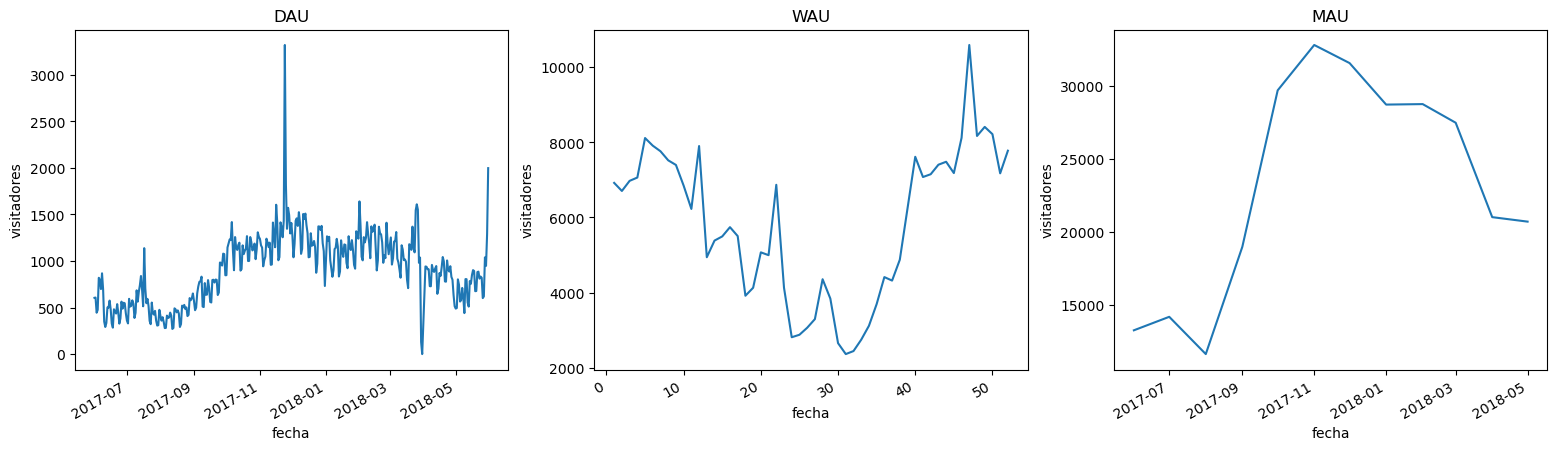

In [263]:
fig, ax = plt.subplots(1, 3, figsize=(19,5))
ax[0].plot(dau)
ax[0].set(title='DAU', xlabel='fecha', ylabel='visitadores')
ax[1].plot(wau)
ax[1].set(title='WAU', xlabel='fecha', ylabel='visitadores')
ax[2].plot(mau)
ax[2].set(title='MAU', xlabel='fecha', ylabel='visitadores')
fig.autofmt_xdate(rotation=30)
plt.show()

In [264]:
# Sesiones por usuario

sesiones_por_usuario = visitas.groupby('sesion_fecha').agg({'uid': ['count', 'nunique']})

In [265]:
sesiones_por_usuario.columns = ['n_sesiones', 'n_usuarios']

In [266]:
sesiones_por_usuario['sessiones_por_usuario'] = sesiones_por_usuario['n_sesiones'] / sesiones_por_usuario['n_usuarios']

<Axes: xlabel='sesion_fecha'>

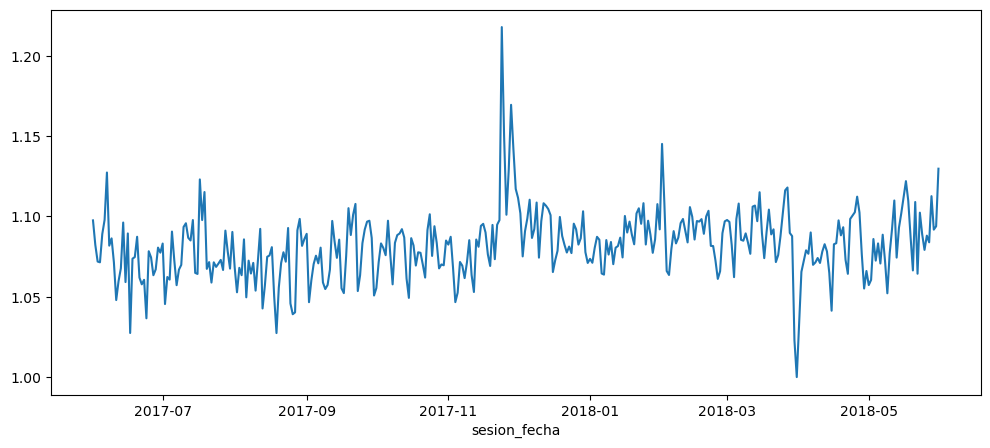

In [267]:
plt.figure(figsize=(12,5))
sesiones_por_usuario['sessiones_por_usuario'].plot()

In [268]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27


In [269]:
visitas['duracion_sesion_seg'] = (visitas['end_ts'] - visitas['start_ts']).dt.seconds

In [270]:
visitas['duracion_sesion_seg']

0         1080
1         1680
2            0
3         1440
4            0
          ... 
359395      19
359396      19
359397      19
359398      19
359399      19
Name: duracion_sesion_seg, Length: 359400, dtype: int32

<Axes: >

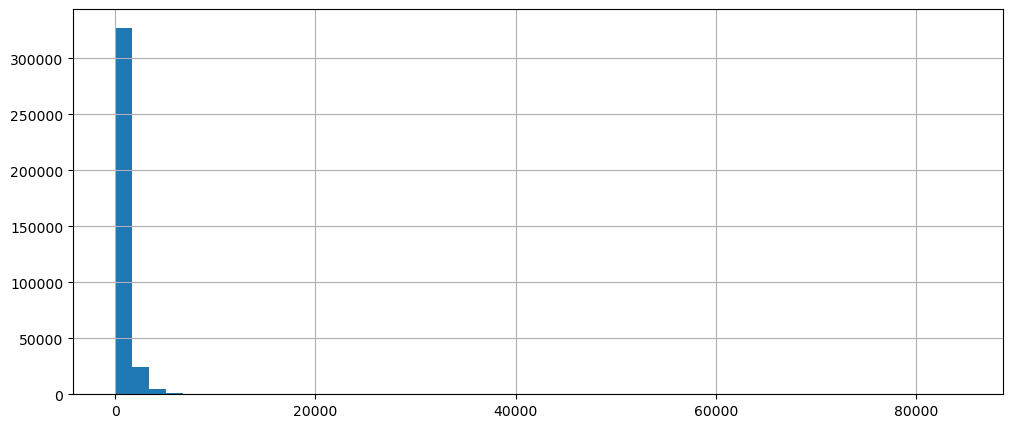

In [271]:
plt.figure(figsize=(12,5))
visitas['duracion_sesion_seg'].hist(bins=50)

In [272]:
visitas['duracion_sesion_seg'].mean()

643.506488592098

In [273]:
visitas['duracion_sesion_seg'].median()

300.0

In [274]:
# Cual es el procentaje de retencion de los usuarios
# Retention Rate

In [275]:
visitas.head()

,device,end_ts,source_id,start_ts,uid,sesion_mes,sesion_semana,sesion_fecha,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-01,51,2017-12-20,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-01,8,2018-02-19,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-01,20,2018-05-20,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-01,52,2017-12-27,0


In [276]:
primeras_visitas = visitas.groupby('uid').agg({'start_ts': 'min'}).reset_index()

In [277]:
primeras_visitas.columns = ['uid', 'inicio_primera_sesion_ts']

In [278]:
primeras_visitas['primera_sesion_fecha'] = primeras_visitas['inicio_primera_sesion_ts'].dt.date
primeras_visitas['primera_sesion_mes'] = pd.to_datetime(primeras_visitas['inicio_primera_sesion_ts'].dt.strftime('%Y-%m-01'))

In [279]:
primeras_visitas

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes
0,11863502262781,2018-03-01 17:27:00,2018-03-01,2018-03-01
1,49537067089222,2018-02-06 15:55:00,2018-02-06,2018-02-01
2,297729379853735,2017-06-07 18:47:00,2017-06-07,2017-06-01
3,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01
4,325320750514679,2017-09-30 14:29:00,2017-09-30,2017-09-01
...,...,...,...,...
228164,18446403737806311543,2017-11-30 03:36:00,2017-11-30,2017-11-01
228165,18446424184725333426,2017-12-06 20:32:00,2017-12-06,2017-12-01
228166,18446556406699109058,2018-01-01 16:29:00,2018-01-01,2018-01-01
228167,18446621818809592527,2017-12-27 13:27:00,2017-12-27,2017-12-01


In [280]:
visitas_full = pd.merge(primeras_visitas, visitas, on = 'uid', how='inner')

In [281]:
import numpy as np

In [282]:
visitas_full['edad_meses'] = ((visitas_full['sesion_mes'] - visitas_full['primera_sesion_mes']) / (30 * np.timedelta64(1, 'D'))).round().astype('int')

In [283]:
cohortes_visitas = visitas_full.pivot_table(
    index='primera_sesion_mes',
    columns='edad_meses',
    values='uid',
    aggfunc='nunique'
)

In [284]:
cohortes_visitas.fillna(0, inplace=True)

In [285]:
cohortes_visitas

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_sesion_mes,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0,0.0
2017-08-01,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0,0.0,0.0
2017-09-01,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0,0.0,0.0,0.0
2017-10-01,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0,0.0,0.0,0.0,0.0
2017-11-01,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0,0.0,0.0,0.0,0.0,0.0
2017-12-01,25268.0,1410.0,960.0,786.0,512.0,481.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-01,22624.0,1351.0,890.0,565.0,458.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-02-01,22197.0,1267.0,565.0,446.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [286]:
retention = pd.DataFrame()

In [287]:
for col in cohortes_visitas.columns:
    retention = pd.concat([retention, cohortes_visitas[col]/cohortes_visitas[0]], axis = 1)

In [288]:
retention.columns = cohortes_visitas.columns

In [289]:
retention.index = [str(indice)[:10] for indice in retention.index]

[Text(0.5, 1.0, 'Ratio de retencion')]

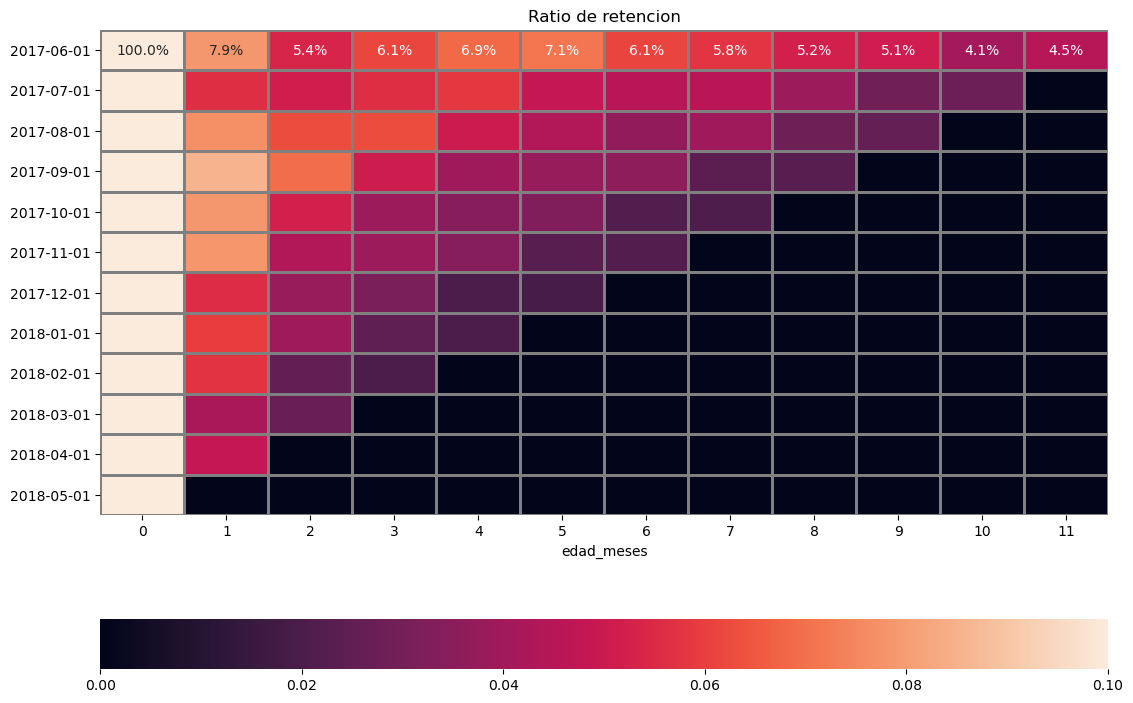

In [290]:
import seaborn as sns
plt.figure(figsize=(13,9))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1%',
    linewidths=1,
    linecolor='grey',
    vmax=0.1,
    cbar_kws={'orientation': 'horizontal'}
).set(title = 'Ratio de retencion')

In [291]:
# Cuando los clientes empiezas a comprar?

In [292]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [293]:
ordenes['compra_mes'] = pd.to_datetime(ordenes['buy_ts'].dt.strftime('%Y-%m-01'))

In [294]:
primeras_compras = ordenes.groupby('uid').agg({'buy_ts': 'min'}).reset_index()

In [295]:
primeras_compras.columns = ['uid', 'primera_compra']

In [296]:
primeras_compras['primera_compra_fecha'] = primeras_compras['primera_compra'].dt.date

In [297]:
primeras_compras['primera_compra_mes'] = pd.to_datetime(primeras_compras['primera_compra'].dt.strftime('%Y-%m-01'))

In [298]:
compradores = pd.merge(primeras_visitas, primeras_compras, on = 'uid')

In [299]:
compradores

,uid,inicio_primera_sesion_ts,primera_sesion_fecha,primera_sesion_mes,primera_compra,primera_compra_fecha,primera_compra_mes
0,313578113262317,2017-09-18 22:49:00,2017-09-18,2017-09-01,2018-01-03 21:51:00,2018-01-03,2018-01-01
1,1575281904278712,2017-06-03 10:13:00,2017-06-03,2017-06-01,2017-06-03 10:13:00,2017-06-03,2017-06-01
2,2429014661409475,2017-10-11 17:14:00,2017-10-11,2017-10-01,2017-10-11 18:33:00,2017-10-11,2017-10-01
3,2464366381792757,2018-01-27 20:10:00,2018-01-27,2018-01-01,2018-01-28 15:54:00,2018-01-28,2018-01-01
4,2551852515556206,2017-11-24 10:14:00,2017-11-24,2017-11-01,2017-11-24 10:14:00,2017-11-24,2017-11-01
...,...,...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-08-20,2017-08-01,2017-11-24 09:03:00,2017-11-24,2017-11-01
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22,2017-09-01,2017-09-22 23:55:00,2017-09-22,2017-09-01
36520,18445601152732270159,2017-08-07 11:51:00,2017-08-07,2017-08-01,2018-03-26 22:54:00,2018-03-26,2018-03-01
36521,18446156210226471712,2017-11-07 10:01:00,2017-11-07,2017-11-01,2018-02-18 19:34:00,2018-02-18,2018-02-01


In [300]:
# Cuanto dias pasan hasta la primera compra (desde la primera visita)?

In [301]:
compradores['dias_hasta_la_primera_compra'] = ((compradores['primera_compra'] - compradores['inicio_primera_sesion_ts']) / np.timedelta64(1, 'D')).astype('int')

In [302]:
compradores['dias_hasta_la_primera_compra']

0        106
1          0
2          0
3          0
4          0
        ... 
36518     95
36519      0
36520    231
36521    103
36522      0
Name: dias_hasta_la_primera_compra, Length: 36523, dtype: int64

In [303]:
import plotly.express as px

In [304]:
px.histogram(compradores['dias_hasta_la_primera_compra'])

In [305]:
# Como se ven las compras por cohorte

In [306]:
# Encontrar el numero de clientes por cada cohorte

In [307]:
tamano_cohorte = compradores.groupby('primera_compra_mes').agg({'uid': 'nunique'}).reset_index()

In [308]:
tamano_cohorte.columns = ['primera_compra_mes', 'n_compradores']

In [309]:
cohortes = pd.merge(ordenes, compradores, how='inner', on='uid')

In [310]:
cohortes = cohortes.groupby(['primera_compra_mes', 'compra_mes']).agg({'uid':'count', 'revenue': 'sum'}).reset_index()

In [311]:
cohortes['edad_meses'] = ((cohortes['compra_mes'] - cohortes['primera_compra_mes'])/(30*np.timedelta64(1, 'D'))).round().astype('int')

In [312]:
cohortes.columns = ['primera_compra_mes', 'compra_mes', 'n_ordenes', 'venta_total', 'edad_meses']

In [313]:
cohortes

,primera_compra_mes,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2017-06-01,2354,9557.49,0
1,2017-06-01,2017-07-01,177,981.82,1
2,2017-06-01,2017-08-01,174,885.34,2
3,2017-06-01,2017-09-01,226,1931.30,3
4,2017-06-01,2017-10-01,292,2068.58,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,176,1114.87,2
75,2018-04-01,2018-04-01,2495,10600.69,0
76,2018-04-01,2018-05-01,195,1209.92,1
77,2018-05-01,2018-05-01,3249,13925.76,0


In [314]:
# Customer Lifetime Value

In [315]:
tamano_cohorte

,primera_compra_mes,n_compradores
0,2017-06-01,2023
1,2017-07-01,1923
2,2017-08-01,1370
3,2017-09-01,2581
4,2017-10-01,4340
5,2017-11-01,4081
6,2017-12-01,4383
7,2018-01-01,3373
8,2018-02-01,3651
9,2018-03-01,3533


In [316]:
cohortes

,primera_compra_mes,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2017-06-01,2354,9557.49,0
1,2017-06-01,2017-07-01,177,981.82,1
2,2017-06-01,2017-08-01,174,885.34,2
3,2017-06-01,2017-09-01,226,1931.30,3
4,2017-06-01,2017-10-01,292,2068.58,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,176,1114.87,2
75,2018-04-01,2018-04-01,2495,10600.69,0
76,2018-04-01,2018-05-01,195,1209.92,1
77,2018-05-01,2018-05-01,3249,13925.76,0


In [317]:
reporte_cohortes = pd.merge(tamano_cohorte, cohortes, how='inner', on='primera_compra_mes')

In [318]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses
0,2017-06-01,2023,2017-06-01,2354,9557.49,0
1,2017-06-01,2023,2017-07-01,177,981.82,1
2,2017-06-01,2023,2017-08-01,174,885.34,2
3,2017-06-01,2023,2017-09-01,226,1931.30,3
4,2017-06-01,2023,2017-10-01,292,2068.58,4
...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2
75,2018-04-01,2276,2018-04-01,2495,10600.69,0
76,2018-04-01,2276,2018-05-01,195,1209.92,1
77,2018-05-01,2988,2018-05-01,3249,13925.76,0


In [319]:
reporte_cohortes['ordenes_por_comprador'] = reporte_cohortes['n_ordenes'] / reporte_cohortes['n_compradores']

In [320]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses,ordenes_por_comprador
0,2017-06-01,2023,2017-06-01,2354,9557.49,0,1.163618
1,2017-06-01,2023,2017-07-01,177,981.82,1,0.087494
2,2017-06-01,2023,2017-08-01,174,885.34,2,0.086011
3,2017-06-01,2023,2017-09-01,226,1931.30,3,0.111715
4,2017-06-01,2023,2017-10-01,292,2068.58,4,0.144340
...,...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2,0.049816
75,2018-04-01,2276,2018-04-01,2495,10600.69,0,1.096221
76,2018-04-01,2276,2018-05-01,195,1209.92,1,0.085677
77,2018-05-01,2988,2018-05-01,3249,13925.76,0,1.087349


In [321]:
# Primera version del LTV

In [322]:
cohortes_ltv_1 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ordenes_por_comprador',
    aggfunc='sum'
)

In [323]:
cohortes_ltv_1.round(2).fillna(0, inplace=True)

In [324]:
cohortes_ltv_1

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,1.163618,0.087494,0.086011,0.111715,0.144340,0.107761,0.136431,0.086011,0.104795,0.075630,0.047454,0.042511
2017-07-01,1.136765,0.052002,0.062402,0.054082,0.037441,0.042642,0.031721,0.026001,0.030161,0.012480,0.027561,NaN
2017-08-01,1.118978,0.078832,0.072993,0.059124,0.062044,0.045255,0.035766,0.056934,0.033577,0.033577,NaN,NaN
2017-09-01,1.136381,0.084851,0.062379,0.063541,0.025959,0.042232,0.041844,0.021697,0.023634,NaN,NaN,NaN
2017-10-01,1.143779,0.072350,0.037327,0.028111,0.029724,0.023733,0.019816,0.028802,NaN,NaN,NaN,NaN
2017-11-01,1.179368,0.097280,0.044597,0.051703,0.033325,0.014457,0.024994,NaN,NaN,NaN,NaN,NaN
2017-12-01,1.152635,0.061602,0.046087,0.040840,0.019621,0.023956,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,1.121554,0.066410,0.047139,0.018974,0.023125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,1.121611,0.060805,0.022733,0.019173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [332]:
reporte_cohortes

,primera_compra_mes,n_compradores,compra_mes,n_ordenes,venta_total,edad_meses,ordenes_por_comprador,ltv
0,2017-06-01,2023,2017-06-01,2354,9557.49,0,1.163618,4.724414
1,2017-06-01,2023,2017-07-01,177,981.82,1,0.087494,0.485329
2,2017-06-01,2023,2017-08-01,174,885.34,2,0.086011,0.437637
3,2017-06-01,2023,2017-09-01,226,1931.30,3,0.111715,0.954671
4,2017-06-01,2023,2017-10-01,292,2068.58,4,0.144340,1.022531
...,...,...,...,...,...,...,...,...
74,2018-03-01,3533,2018-05-01,176,1114.87,2,0.049816,0.315559
75,2018-04-01,2276,2018-04-01,2495,10600.69,0,1.096221,4.657597
76,2018-04-01,2276,2018-05-01,195,1209.92,1,0.085677,0.531599
77,2018-05-01,2988,2018-05-01,3249,13925.76,0,1.087349,4.660562


In [327]:
reporte_cohortes['ltv'] = reporte_cohortes['venta_total'] / reporte_cohortes['n_compradores']

In [328]:
cohortes_ltv_2 = reporte_cohortes.pivot_table(
    index='primera_compra_mes',
    columns='edad_meses',
    values='ltv',
    aggfunc='sum'
)

In [331]:
cohortes_ltv_2

edad_meses,0,1,2,3,4,5,6,7,8,9,10,11
primera_compra_mes,,,,,,,,,,,,
2017-06-01,4.724414,0.485329,0.437637,0.954671,1.022531,0.735502,0.950440,0.581592,0.553213,0.605788,0.571261,0.256856
2017-07-01,6.010218,0.335211,0.623531,0.358976,0.176791,0.156048,0.120208,0.141820,0.161232,0.147145,0.155673,NaN
2017-08-01,5.276518,0.471993,0.458482,0.391277,0.494051,0.283540,0.210664,0.405007,0.292212,0.187978,NaN,NaN
2017-09-01,5.644529,1.117586,0.520930,3.975792,0.400558,0.647067,0.701608,0.243150,0.184006,NaN,NaN,NaN
2017-10-01,5.003733,0.535763,0.191394,0.157145,0.151560,0.120362,0.084816,0.115470,NaN,NaN,NaN,NaN
2017-11-01,5.154683,0.399233,0.199556,0.324952,0.148013,0.053879,0.114928,NaN,NaN,NaN,NaN,NaN
2017-12-01,4.738191,0.260374,0.925097,1.065275,0.312930,0.338047,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,4.135636,0.294758,0.304281,0.142778,0.062698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,4.156987,0.278274,0.078515,0.074144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
